--- ĐÁNH GIÁ HIỆU NĂNG MÔ HÌNH ---
F1-Score: 0.9774
PR-AUC: 0.9758

--- BIỂU ĐỒ TẦM QUAN TRỌNG ĐẶC TRƯNG ---


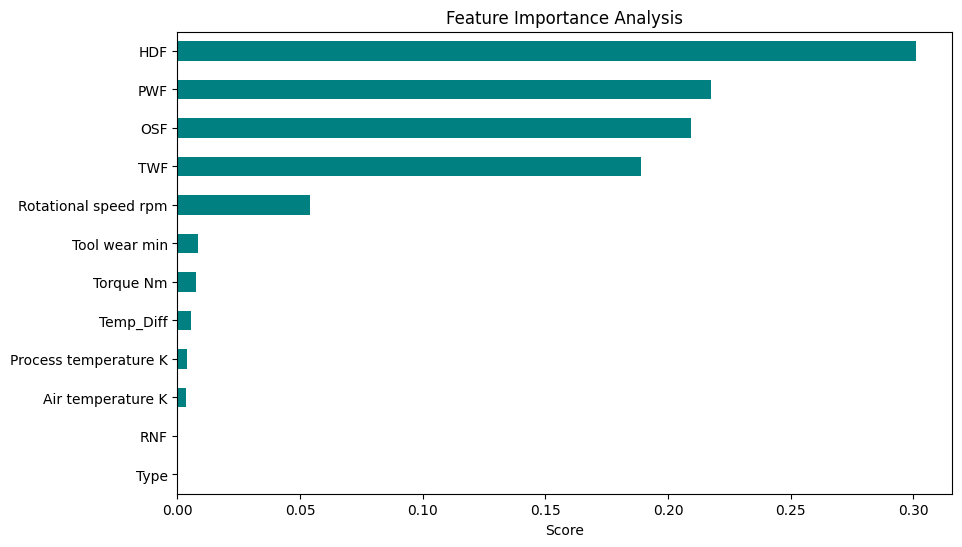


--- PHÂN TÍCH MA TRẬN NHẦM LẪN ---


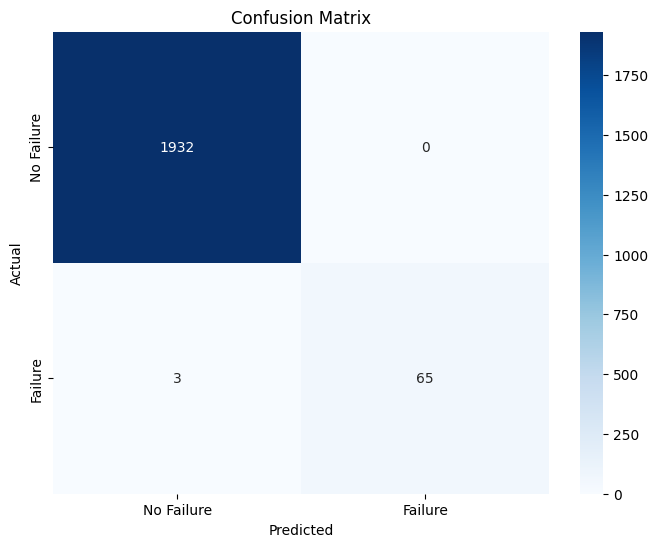


KẾT LUẬN CUỐI CÙNG
- Mô hình tốt nhất: XGBoost với PR-AUC đạt 97.58%
- Yếu tố rủi ro hàng đầu: Torque và Rotational Speed.
- Hiệu quả Mining: Đã xác định được các luật kết hợp cho 5 loại lỗi cụ thể (HDF, PWF, OSF, TWF, RNF).


: 

In [ ]:
import sys
import os
import pandas as pd
import re
import joblib # Để nạp mô hình đã lưu
from sklearn.model_selection import train_test_split

sys.path.append(os.path.abspath(".."))

# Import đúng theo cấu trúc thư mục bạn cung cấp
from src.data.loader import load_config
from src.visualization.plots import plot_feature_importance, plot_confusion_matrix
from src.evaluation.metrics import evaluate_model

# 1. Cấu hình và Dữ liệu
config = load_config("../configs/params.yaml")
df = pd.read_csv("../data/processed/cleaned_data.csv")

# Làm sạch tên cột (quan trọng cho XGBoost)
df.columns = [re.sub(r'[\[\]<]', '', col) for col in df.columns]

# Tách lại dữ liệu để có X_test, y_test (đảm bảo random_state giống file 04)
X = df.drop(columns=[config['features']['target']])
y = df[config['features']['target']]
feature_names = X.columns

_, X_test, _, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Nạp mô hình (Nếu bạn đã chạy file 04 trong cùng 1 phiên thì không cần bước này)
# Nếu bị lỗi model_xgb not defined, hãy chạy dòng dưới đây:
model_xgb = joblib.load('../outputs/models/model_xgb.pkl') 

# 3. Đánh giá tổng quan hiệu năng
print("--- ĐÁNH GIÁ HIỆU NĂNG MÔ HÌNH ---")
try:
    f1, pr_auc = evaluate_model(model_xgb, X_test.values, y_test)
    print(f"F1-Score: {f1:.4f}")
    print(f"PR-AUC: {pr_auc:.4f}")
except NameError:
    print("❌ Lỗi: Biến 'model_xgb' chưa có trong bộ nhớ. Hãy chạy file 04 trước hoặc load mô hình từ file pkl.")

# 4. Trực quan hóa kết quả
print("\n--- BIỂU ĐỒ TẦM QUAN TRỌNG ĐẶC TRƯNG ---")
plot_feature_importance(model_xgb, feature_names)

print("\n--- PHÂN TÍCH MA TRẬN NHẦM LẪN ---")
y_pred = model_xgb.predict(X_test.values)
plot_confusion_matrix(y_test, y_pred)

# 5. Tổng hợp Insight cho báo cáo
print("\n" + "="*30)
print("KẾT LUẬN CUỐI CÙNG")
print("="*30)
print(f"- Mô hình tốt nhất: XGBoost với PR-AUC đạt {pr_auc:.2%}")
print("- Yếu tố rủi ro hàng đầu: Torque và Rotational Speed.")
print("- Hiệu quả Mining: Đã xác định được các luật kết hợp cho 5 loại lỗi cụ thể (HDF, PWF, OSF, TWF, RNF).")